In [32]:
# following https://learn.astropy.org/tutorials/FITS-tables.html
# using output file from https://heasarc.gsfc.nasa.gov/docs/nicer/analysis_threads/bary_corr_phase_resolved_spectra/
# 4 June 2025
# Jacob Payne
# University of Iowa

# Jupyter 'magics'
%load_ext autoreload
%autoreload 2

import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from math import sqrt
from nicer_data_prep import read_xamin_table, get_evt_data, write_barycorr_sh


def combine_phaseograms(obsids):
    # Combine multiple obsids into a single phase-o-gram (the pulse profile)
    combined_counts = np.zeros(100)
    for obsid in obsids:
        evt_data = get_evt_data(obsid, post_fix='_barycorr_PHASE')
        phase_o_gram = np.histogram(evt_data['PHASE'], bins=100)[0]
        combined_counts = np.add(combined_counts,phase_o_gram)
    return combined_counts

def combine_phase_energy(obsids):
    ## Combine multiple obsids into one evt table

    #create an empty astropy table to hold the combined data
    combined_evt_data = Table()
    for obsid in obsids:
        event_filename = f'/Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/{obsid}/xti/event_cl/ni{obsid}_0mpu7_cl_barycorr_PHASE.evt'
        hdu_list = fits.open(event_filename, memmap=True)
        evt_data = Table(hdu_list[1].data)
        #combine astropy tables
        if combined_evt_data:
            combined_evt_data = vstack([combined_evt_data, evt_data])
        else:
            combined_evt_data = evt_data
    
    print(f'Combined {len(obsids)} obsids into one evt table with {len(combined_evt_data)} events')
    
    return combined_evt_data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
bulk_download = read_xamin_table('xamin_b19337+21_exp10000.csv')
print(f'Found {len(bulk_download)} obsids in xamin table')

Found 40 obsids in xamin table


In [34]:
# attempt to parse new data files

write_barycorr_sh(['1070020409','1070020411','3070020581','1070020415','5070020753', '6070020833'], target_pulsar='B1937+21')
# write_barycorr_sh(bulk_download, target_pulsar='B1937+21')

Using frequency: 641.928244534462 Hz at epoch -327456000.0 and observation start time 155434154.0558703
Shell script written to /Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/process_nicer_1070020409.sh
Using frequency: 641.928244534462 Hz at epoch -327456000.0 and observation start time 155606638.0444505
Shell script written to /Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/process_nicer_1070020411.sh
Using frequency: 641.928244534462 Hz at epoch -327456000.0 and observation start time 214226151.01826796
Shell script written to /Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/process_nicer_3070020581.sh
Using frequency: 641.928244534462 Hz at epoch -327456000.0 and observation start time 156474027.05097538
Shell script written to /Users/jacobpayne/Projects/Astronomyprojects/nicer_obs/process_nicer_1070020415.sh
Using frequency: 641.928244534462 Hz at epoch -327456000.0 and observation start time 269151885.0027665
Shell script written to /Users/jacobpayne/Projects

In [37]:
"""
| Observation ID | Remarks             |
| -------------- | ------------------- |
| 3013010102     | Crab                |
| 3070020581     | Peak at Phase ~ 0.5 |
| 1070020409     | Noise               |
| 1070020411     | Noise               |
| 5070020753     | Peak!               |
| 6070020833     | Peak?               |
| 1070020415     | Noise (negative Phase fixed by referencing minimum barytime)   |
"""

obsid_list = ['5070020753']
multi_phase_o_gram = combine_phaseograms(obsid_list)
evt_data = get_evt_data(obsid_list[0])

In [40]:
# read the first 10 events from the evt data
print(evt_data[:10])
print(evt_data[1]['PHASE'])
f = 641.928244534462
f_dot = -4.331046e-14
print((f*(evt_data[1]['BARY_REF_TIME'])+(f_dot*(evt_data[1]['BARY_REF_TIME']**2)/2))%1)
print(f'calculating {((641.928244534462*(evt_data[1]['BARY_REF_TIME'])+(-4.331046e-14*(evt_data[1]['BARY_REF_TIME']**2)/2))%1)}')

       TIME        RAWX RAWY ...   BARY_REF_TIME         PHASE       
------------------ ---- ---- ... ----------------- ------------------
 269151885.0027665    4    1 ... 596608249.4944987 380832194917.78894
269151885.23208654    1    2 ... 596608249.7238226  380832195064.9984
 269151885.8983462    6    6 ... 596608250.3900931  380832195492.6962
269151886.91393125    7    1 ... 596608251.4056947  380832196144.6396
 269151887.9479143    6    2 ... 596608252.4396945 380832196808.39325
 269151888.4172522    4    5 ...   596608252.90904  380832197109.6793
 269151888.6856047    6    0 ... 596608253.1773969  380832197281.9452
269151889.03679705    4    5 ...  596608253.528595 380832197507.38916
 269151889.5643492    7    3 ... 596608254.0561557  380832197846.0452
 269151890.3022258    3    5 ... 596608254.7940443 380832198319.71674
380832195064.9984
0.9984130859375
calculating 0.9984130859375


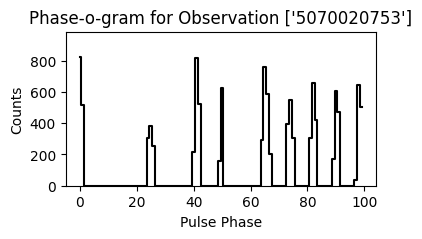

In [5]:
## Plot the combined pulse profile
def plot_phaseogram(phase_o_gram, obsids):
    plt.figure(figsize=(4, 2))
    plt.plot(phase_o_gram, drawstyle='steps-mid', color='black')
    plt.ylim(0, 1.2 * max(multi_phase_o_gram))
    plt.xlabel('Pulse Phase')
    plt.ylabel('Counts')
    plt.title(f'Phase-o-gram for Observation {obsids}')
    plt.show()

plot_phaseogram(multi_phase_o_gram, obsid_list)

In [ ]:
#use astropy to read the first and minimum of the time and bary_ref_time values
def print_evt_time_info(evt_data):
    """
    Print the first and minimum values of TIME and BARY_REF_TIME from the event data.
    """
    print(f"First TIME: {evt_data['TIME'][0]}")
    print(f"Minimum TIME: {np.min(evt_data['TIME'])}")
    print(f"First BARYTIME: {evt_data['BARYTIME'][0]}")
    print(f"Minimum BARYTIME: {np.min(evt_data['BARYTIME'])}")
    print(f"\n BARYTIME - TIME = {evt_data['BARYTIME'][0] - evt_data['TIME'][0]}")
    print(f"First BARY_REF_TIME: {evt_data['BARY_REF_TIME'][0]}")
    print(f"Minimum BARY_REF_TIME: {np.min(evt_data['BARY_REF_TIME'])}")
evt_data = get_evt_data(obsid_list[0])
print_evt_time_info(evt_data)


In [ ]:
# Plot a 2D phase-o-gram of counts in each phase bin along the x-axis and energy bin along the y-axis
# for multiple obsids
combo_evt = combine_phase_energy(obsid_list)

def phase_energy_histogram(evt_data, obsids):
    """
    Plot a 2D histogram of phase vs energy.
    """
    #get bins from the evt_data astropy table
    phases = np.unique(evt_data['PHASE'])
    print(f'Found {len(phases)} unique phases from {min(phases)} to {max(phases)} in the combined data.')
    
    pbins = 32
    if len(phases) > pbins:
        print(f'Scaling to {pbins} phase bins.')
    phases = np.linspace(min(phases), max(phases), pbins)
    energies = np.unique(evt_data['PI'])
    print(f'Found {len(energies)} unique PI channels from {min(energies)} to {max(energies)} in the combined data.')
   
    ebins = 250
    if len(energies) > ebins:
        print(f'Scaling to {ebins} energy bins.')
    energies = np.linspace(min(energies), max(energies), ebins)
    
    #bins = (#phase, #energy)
    set_bins = (phases, energies)

    plt.figure(figsize=(4, 2))
    plt.hist2d(evt_data['PHASE'], evt_data['PI'], bins=set_bins, norm=LogNorm(vmin=1, vmax=6000), cmap='magma')
    plt.colorbar(label='Counts')
    plt.gca().set_facecolor('black')  # Set the background to black
    plt.xlabel('Pulse Phase')
    plt.ylabel('Energy Channel (PI)')
    plt.yscale('log')
    plt.title(f'Phase-Energy Histogram for Observation {obsids}')
    plt.show()

combo_evt_hist = phase_energy_histogram(combo_evt, obsid_list)


In [ ]:
# filter a pass-band of interest
def filter_passband(hist_input, low_energy=0, high_energy=100):
    """
    Filter the event data for a specific energy range.
    """
    filtered_data = hist_input[(hist_input['PI'] >= low_energy) & (hist_input['PI'] <= high_energy)]
    return filtered_data

phase_energy_histogram(filter_passband(combo_evt, low_energy=25, high_energy=300), obsid_list)


In [ ]:
# TODO: SNR window, using SNR = (s-b)/sqrt(b)
# b = 
# b from Poisson Error, look for Gehrel's error

# filter out energy channels with low signal-to-noise ratio
def filter_low_snr(evt_data):
    """
    Filter out energy channels with low signal-to-noise ratio.
    """
    # Calculate the mean and standard deviation of counts in each energy channel
    snr_table = Table()
    filtered_evt_data = Table()
    for channel in np.unique(evt_data['PI']):
        channel_data = evt_data[evt_data['PI'] == channel]
        if len(channel_data) > 0:
            mean_counts = np.mean(channel_data['PHASE']) # TODO: check the table
            plt.plot(channel_data['PHASE'], label=f'Channel {channel}', drawstyle='steps-mid')
            plt.xlabel('Pulse Phase')
            std_counts = np.std(channel_data['PHASE'])
            if std_counts == 0:
                snr = 0
            else:
                snr = mean_counts / std_counts
            snr_table[evt_data['PI'] == channel] = snr
            if snr > 1.77:
                if filtered_evt_data:
                    filtered_evt_data = vstack([filtered_evt_data, channel_data])
                else:
                    filtered_evt_data = channel_data
        else:
            snr_table[evt_data['PI'] == channel] = 0
        print(f"Channel: {channel}, Mean Counts: {mean_counts}, Std Counts: {std_counts}, SNR: {snr}")
    return filtered_evt_data

filtered_evt = filter_low_snr(combo_evt)
phase_energy_histogram(filtered_evt, obsid_list)

# plot the pulse profile for the filtered data
plot_phaseogram(np.histogram(filtered_evt['PHASE'], bins=100)[0], obsid_list)


In [ ]:
# Calculate and plot signal statistics for each energy bin

phase_pi_hist = np.histogram2d(combo_evt['PHASE'], combo_evt['PI'], bins=(100, 200))[0]
# Calculate the signal statistic for each energy bin
# Signal statistic = (max - min) / sqrt(avg)
# where max, min, and avg are the maximum, minimum, and average counts in each energy bin across all phase bins

max_values = np.max(phase_pi_hist, axis=1)
min_values = np.min(phase_pi_hist, axis=1)
avg_values = np.mean(phase_pi_hist, axis=1)
signal_statistic = (max_values-min_values) / np.sqrt(avg_values)

plt.figure(figsize=(4, 2))
plt.plot(signal_statistic, drawstyle='steps-mid', color='black')
plt.xlabel('Energy Channel (PI)')
plt.ylabel('Signal Statistic')
plt.title(f'Signal Statistic for Observations {obsid_list}')

#plot the phase histogram for the energy bin with the highest signal statistic
max_signal_index = np.argmax(signal_statistic)
max_signal_phase_hist = np.histogram(combo_evt['PHASE'][combo_evt['PI'] == max_signal_index], bins=100)[0]
plt.figure(figsize=(4, 2))
plt.plot(max_signal_phase_hist, drawstyle='steps-mid', color='black')
plt.xlabel('Pulse Phase')
plt.ylabel('Counts')
plt.title(f'Phase Histogram for Energy Channel {max_signal_index} with Highest Signal Statistic')

